In [70]:
from math import sqrt as sqrt
import matplotlib.pyplot as plt
import random
import numpy as np 

# Helper Functions

In [71]:
from util.encoding import WorkerEncoding
from util.benchmark_parser import WorkerBenchmarkParser
import random as random
class Instance:
    def __init__(self,encoding:WorkerEncoding,options_map):
        self.encoding=encoding
        self.options_map=options_map
        self.operation_sequence=list(encoding.job_sequence())
        random.shuffle(self.operation_sequence)
        self.worker_machine_sequence=[]
        for op_idx in range(encoding.n_operations()):
            choice=random.choice(self.options_map[op_idx])
            self.worker_machine_sequence.append(choice)
        self.objectives = {"makespan": float('inf'), "balance": float('inf')} 
        self.fitness=0.0
        
    @staticmethod
    def create_options(w_encoding:WorkerEncoding):
        options={}
        for op_idx in range(w_encoding.n_operations()):
            options[op_idx]=[]
            machines=w_encoding.get_machines_for_operation(op_idx)
            for machine_idx in machines:
                worker=w_encoding.get_workers_for_operation_on_machine(op_idx,machine_idx)
                for worker_idx in worker:
                    duration=w_encoding.durations()[op_idx,machine_idx,worker_idx]
                    options[op_idx].append((machine_idx,worker_idx,duration))
        return options
    def swapping(self,mutation_rate:float):
        #Here we perform the swapping of the tuples
        for op_index in range(len(self.worker_machine_sequence)):
            if random.random()<mutation_rate:
                new_possible_values=self.options_map[op_index]
                assignment_value=random.choice(new_possible_values)
                self.worker_machine_sequence[op_index]=assignment_value
        #Here we just swap the job IDs
        if random.random()<mutation_rate:
            idx1, idx2 = random.sample(range(len(self.operation_sequence)), 2)
            self.operation_sequence[idx1],self.operation_sequence[idx2]=self.operation_sequence[idx2],self.operation_sequence[idx1]

    @staticmethod
    def uniform_crossover(parent_A:Instance,parent_B:Instance,mutation_rate:float):
        child1=[]
        child2=[]
        for i in range(len(parent_A.worker_machine_sequence)):
            if random.random()<0.5:
                child1.append(parent_A.worker_machine_sequence[i])
                child2.append(parent_B.worker_machine_sequence[i])
            else:
                child1.append(parent_B.worker_machine_sequence[i])
                child2.append(parent_A.worker_machine_sequence[i])

        return child1,child2
    
    @staticmethod
    def jox_crossover(parent_A:Instance,parent_B:Instance):
        unique_jobs_set=parent_A.operation_sequence+parent_B.operation_sequence
        unique_jobs_set=set(unique_jobs_set)
        unique_jobs=list(unique_jobs_set)
        
        job_selection=random.sample(unique_jobs,len(unique_jobs)//2)
        child=[None]*len(parent_A.operation_sequence)
        for i in range(len(parent_A.operation_sequence)):
            if parent_A.operation_sequence[i] in job_selection:
                child[i]=parent_A.operation_sequence[i]
        pointer=0
        for i in range(len(child)):
            if child[i]==None:
                while parent_B.operation_sequence[pointer] in job_selection:
                    pointer+=1
               
                child[i]=parent_B.operation_sequence[pointer]
                pointer+=1
        return child
    
    @staticmethod
    def breeding(parent_A:Instance,parent_B:Instance, mutation_rate:float):
        child_operation_sequence=Instance.jox_crossover(parent_A,parent_B)
        child1,child2=Instance.uniform_crossover(parent_A,parent_B,mutation_rate)

        child_worker_operation=child1 if random.random()<0.5 else child2
        
        child=Instance(parent_A.encoding,parent_A.options_map)
        child.operation_sequence=child_operation_sequence
        child.worker_machine_sequence=child_worker_operation
        child.swapping(mutation_rate)

        return child

parser = WorkerBenchmarkParser()
encoding = parser.parse_benchmark(r'instances/fjssp-w/3_DPpaulli_1_workers.fjs')

# Call the static method
all_options = Instance.create_options(encoding)
inst=Instance(encoding,all_options)
print(len(inst.operation_sequence))
print(len(inst.worker_machine_sequence))
print(inst.operation_sequence.count(0))
  

Total operations for job 1: 15
	Options for operation 1 (index 0): 1
		Option 1: Machine 1
			Worker options: 7
				(Worker 1, duration 45)
				(Worker 2, duration 38)
				(Worker 3, duration 42)
				(Worker 4, duration 40)
				(Worker 5, duration 43)
				(Worker 6, duration 42)
				(Worker 7, duration 44)
	Options for operation 2 (index 1): 1
		Option 1: Machine 3
			Worker options: 2
				(Worker 2, duration 62)
				(Worker 5, duration 66)
	Options for operation 3 (index 2): 1
		Option 1: Machine 5
			Worker options: 6
				(Worker 1, duration 22)
				(Worker 2, duration 21)
				(Worker 3, duration 21)
				(Worker 4, duration 24)
				(Worker 5, duration 21)
				(Worker 6, duration 21)
	Options for operation 4 (index 3): 1
		Option 1: Machine 4
			Worker options: 6
				(Worker 1, duration 16)
				(Worker 2, duration 15)
				(Worker 3, duration 17)
				(Worker 4, duration 15)
				(Worker 5, duration 15)
				(Worker 7, duration 17)
	Options for operation 5 (index 4): 3
		Option 1: Machine

# SPEA Algorithm

# Constraints

In [72]:
def calculate_fitness(instance:Instance):
    n_machines=instance.encoding.n_machines()
    n_workers=instance.encoding.n_workers()
    n_jobs=instance.encoding.n_jobs()
    worker_timer=[0]*n_workers
    machines_timer=[0]*n_machines
    jobs_timer=[0]*n_jobs
    job_counter=[0]*n_jobs
    worker_balance=[0]*n_workers

    job_start_indices = [0] * n_jobs
    current_offset = 0
    for j in range(n_jobs):
        job_start_indices[j] = current_offset
        ops = instance.encoding.get_operations_for_job(j)
        
        count = len(ops) if isinstance(ops, list) else ops
        current_offset += count

    for job_id in instance.operation_sequence:
        job_num=job_counter[job_id]

        operation_index=job_start_indices[job_id]+job_num

        machine,worker,duration=instance.worker_machine_sequence[operation_index]

        start_time=max(worker_timer[worker],machines_timer[machine],jobs_timer[job_id])
        end_time=start_time+duration
        
        worker_timer[worker]=end_time
        machines_timer[machine]=end_time
        jobs_timer[job_id]=end_time
        worker_balance[worker]+=duration

        job_counter[job_id]+=1

    makespan=np.max(jobs_timer)

    worker_balance_fitness=np.std(worker_balance)
    
    return makespan,worker_balance_fitness


# Algorithm

In [73]:
def dominance_function_raw_fitness_combined(population,archive):
   combined=population+archive
   for individual_a in combined:
      individual_a.strength=0
      individual_a.raw_score=0

   for individual_a in combined:
      for individual_b in combined:
         if (individual_a.makespan <= individual_b.makespan and individual_a.worker_balance_fitness <= individual_b.worker_balance_fitness) and (individual_a.makespan < individual_b.makespan or individual_a.worker_balance_fitness < individual_b.worker_balance_fitness):
                individual_a.strength += 1

   for individual_a in combined:
        for individual_b in combined:
            if (individual_b.makespan <= individual_a.makespan and individual_b.worker_balance_fitness <= individual_a.worker_balance_fitness) and \
               (individual_b.makespan < individual_a.makespan or individual_b.worker_balance_fitness < individual_a.worker_balance_fitness):
                individual_a.raw_score += individual_b.strength
   return combined
def euclidean_distance(x1, y1, x2, y2):
   return sqrt(((x1-y1)**2)+((x2-y2)**2))
def density_function(population,archive):
   combined=dominance_function_raw_fitness_combined(population,archive)
   
   max_m = max(individual.makespan for individual in combined)
   min_m = min(individual.makespan for individual in combined)
   max_b = max(individual.worker_balance_fitness for individual in combined)
   min_b = min(individual.worker_balance_fitness for individual in combined)

   range_m = (max_m - min_m) if max_m != min_m else 1
   range_b = (max_b - min_b) if max_b != min_b else 1
   
   k=int(sqrt(len(combined)))
   for individual_a in combined:
      distances=[]
      norm_m_a = (individual_a.makespan - min_m) / range_m
      norm_b_a=(individual_a.worker_balance_fitness-min_b)/range_b
      for individual_b in combined:
         if individual_a==individual_b:
            continue
         norm_m_b = (individual_b.makespan - min_m) / range_m
         norm_b_b=(individual_b.worker_balance_fitness-min_b)/range_b

         distance= euclidean_distance(norm_m_a,norm_b_a,norm_m_b,norm_b_b)
         distances.append(distance)
      distances.sort()
      density=1/(distances[k-1]+2)
      individual_a.final_fitness=individual_a.raw_score+density
      
   return combined
def truncate_archive(archive, archive_size):
   
   while len(archive)>archive_size:
      max_m = max(individual.makespan for individual in archive)
      min_m = min(individual.makespan for individual in archive)
      max_b = max(individual.worker_balance_fitness for individual in archive)
      min_b = min(individual.worker_balance_fitness for individual in archive)

      range_m = (max_m - min_m) if max_m != min_m else 1
      range_b = (max_b - min_b) if max_b != min_b else 1

      neighbour_distances=[]
      for individual_a in archive:
         all_distances=[]
         norm_m_a = (individual_a.makespan - min_m) / range_m
         norm_b_a=(individual_a.worker_balance_fitness-min_b)/range_b
         for individual_b in archive:
            if individual_a==individual_b:
               continue
            norm_m_b = (individual_b.makespan - min_m) / range_m
            norm_b_b=(individual_b.worker_balance_fitness-min_b)/range_b
            distance= euclidean_distance(norm_m_a,norm_b_a,norm_m_b,norm_b_b)
            all_distances.append(distance)
         all_distances.sort()
         neighbour_distances.append(all_distances)
      victim_index = neighbour_distances.index(min(neighbour_distances))
      archive.pop(victim_index)
   return archive      
def environmental_selection(final_population, archive_size):
   new_archive=[individual for individual in final_population if individual.final_fitness<1]
   if len(new_archive)==archive_size:
      return new_archive
   elif len(new_archive)<archive_size:
      dominated_individuals=[individual for individual in final_population if individual.final_fitness>=1]
      dominated_individuals.sort(key=lambda x:x.final_fitness)
      needed_individuals=archive_size-len(new_archive)
      new_archive.extend(dominated_individuals[:needed_individuals])
      return new_archive
   elif len(new_archive)>archive_size:
      return truncate_archive(new_archive,archive_size)
def binary_tournament(archive, population_size):
   population=[]
   while(len(population)<population_size):
      individual_a=random.choice(archive)
      individual_b=random.choice(archive)
      if individual_a.final_fitness<individual_b.final_fitness:
         parent_a=individual_a
      else:
         parent_a=individual_b
      individual_c=random.choice(archive)
      individual_d=random.choice(archive)
      if individual_c.final_fitness<individual_d.final_fitness:
         parent_b=individual_c
      else:
         parent_b=individual_d
      #Breeding where we have uniform crossover,jux crossover and swapping
      child_genes=Instance.breeding(parent_a,parent_b,mutation_rate=0.05)
      child_genes.makespan,child_genes.worker_balance_fitness=calculate_fitness(child_genes)
      population.append(child_genes)
   return population

In [74]:
POP_SIZE = 200
ARCHIVE_SIZE = 100
MAX_GENERATIONS = 500
MUTATION_RATE = 0.1

history_best_makespan = []
history_avg_makespan = []

print("Initializing population...")
all_options = Instance.create_options(encoding)
population = [Instance(encoding, all_options) for _ in range(POP_SIZE)]
archive = []

for ind in population:
    ind.makespan, ind.worker_balance_fitness = calculate_fitness(ind)

for gen in range(1, MAX_GENERATIONS + 1):
    combined = density_function(population, archive)
    archive = environmental_selection(combined, ARCHIVE_SIZE)
    
    # Track statistics for this generation
    current_best = min(ind.makespan for ind in archive)
    current_avg = sum(ind.makespan for ind in archive) / len(archive)
    
    history_best_makespan.append(current_best)
    history_avg_makespan.append(current_avg)
    
    print(f"Gen {gen:02d} | Best Makespan: {current_best:.1f} | Archive Size: {len(archive)}")

    population = binary_tournament(archive, POP_SIZE)

print("\n Test Run Complete.")




Initializing population...
Gen 01 | Best Makespan: 4793.0 | Archive Size: 100
Gen 02 | Best Makespan: 4624.0 | Archive Size: 100
Gen 03 | Best Makespan: 4624.0 | Archive Size: 100
Gen 04 | Best Makespan: 4624.0 | Archive Size: 100
Gen 05 | Best Makespan: 4569.0 | Archive Size: 100
Gen 06 | Best Makespan: 4569.0 | Archive Size: 100
Gen 07 | Best Makespan: 4569.0 | Archive Size: 100
Gen 08 | Best Makespan: 4569.0 | Archive Size: 100
Gen 09 | Best Makespan: 4569.0 | Archive Size: 100
Gen 10 | Best Makespan: 4569.0 | Archive Size: 100
Gen 11 | Best Makespan: 4535.0 | Archive Size: 100
Gen 12 | Best Makespan: 4497.0 | Archive Size: 100
Gen 13 | Best Makespan: 4497.0 | Archive Size: 100
Gen 14 | Best Makespan: 4413.0 | Archive Size: 100
Gen 15 | Best Makespan: 4413.0 | Archive Size: 100
Gen 16 | Best Makespan: 4413.0 | Archive Size: 100
Gen 17 | Best Makespan: 4398.0 | Archive Size: 100
Gen 18 | Best Makespan: 4398.0 | Archive Size: 100
Gen 19 | Best Makespan: 4324.0 | Archive Size: 100
Gen 

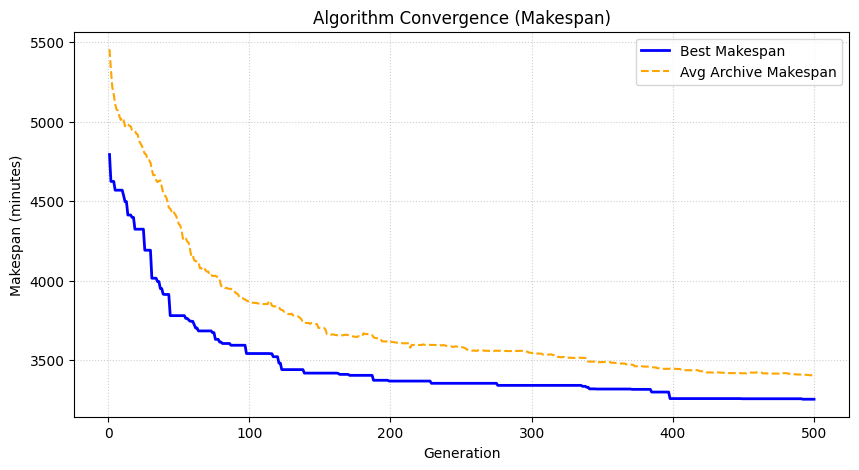

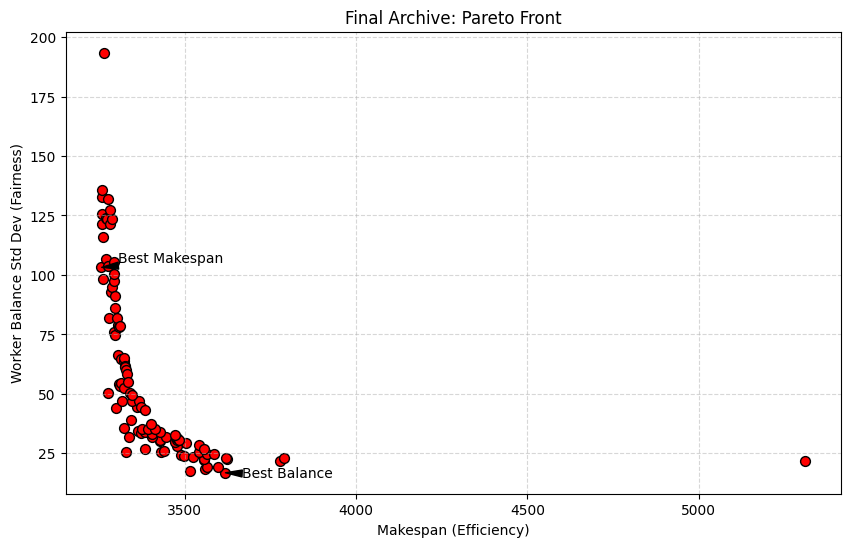

In [75]:
# Plot 1: Convergence Curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, MAX_GENERATIONS + 1), history_best_makespan, label='Best Makespan', color='blue', linewidth=2)
plt.plot(range(1, MAX_GENERATIONS + 1), history_avg_makespan, label='Avg Archive Makespan', color='orange', linestyle='--')
plt.title('Algorithm Convergence (Makespan)')
plt.xlabel('Generation')
plt.ylabel('Makespan (minutes)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

# Plot 2: Final Pareto Front
# Extract values from the final archive
archive_makespans = [ind.makespan for ind in archive]
archive_balance = [ind.worker_balance_fitness for ind in archive]

plt.figure(figsize=(10, 6))
plt.scatter(archive_makespans, archive_balance, color='red', edgecolors='black', s=50)
plt.title('Final Archive: Pareto Front')
plt.xlabel('Makespan (Efficiency)')
plt.ylabel('Worker Balance Std Dev (Fairness)')
plt.grid(True, linestyle='--', alpha=0.5)


best_m = min(archive, key=lambda x: x.makespan)
best_b = min(archive, key=lambda x: x.worker_balance_fitness)

plt.annotate('Best Makespan', xy=(best_m.makespan, best_m.worker_balance_fitness), 
             xytext=(best_m.makespan + 50, best_m.worker_balance_fitness + 2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.annotate('Best Balance', xy=(best_b.makespan, best_b.worker_balance_fitness), 
             xytext=(best_b.makespan + 50, best_b.worker_balance_fitness - 2),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.show()